### Imports

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.lines as mlines
import os
from scipy import stats
from pathlib import Path

### Chemins

In [2]:
# For invoke 
output_dir = Path(os.environ.get("OUTPUT_DATA_DIR", "output_data"))
figures_dir = Path(os.environ.get("FIGURES_DIR", "figures_dir"))
os.makedirs(figures_dir, exist_ok=True)

tableau_resultat = pd.read_csv(output_dir / "resultats.csv", index_col=0)
print(tableau_resultat.columns)

Index(['slice_index', 'sam_dice', 'sam_precision', 'sam_recall', 'sam_HD100',
       'sam_AVG_dist', 'medsam_dice', 'medsam_precision', 'medsam_recall',
       'medsam_HD100', 'medsam_AVG_dist'],
      dtype='str')


### Formater le tableau de résultats pour les figures

In [3]:
# Mettre dans le bon format
df_sam = tableau_resultat[['sam_dice', 'sam_precision', 'sam_recall', 'sam_HD100', 'sam_AVG_dist']].copy()
df_sam.columns = ['dice', 'precision', 'recall', 'HD100', 'AVG_dist']
df_sam['modele'] = 'SAM'

df_medsam = tableau_resultat[['medsam_dice', 'medsam_precision', 'medsam_recall', 'medsam_HD100', 'medsam_AVG_dist']].copy()
df_medsam.columns = ['dice', 'precision', 'recall', 'HD100', 'AVG_dist']
df_medsam['modele'] = 'MedSAM'

df_long = pd.concat([df_sam, df_medsam])

print(df_long.columns)

Index(['dice', 'precision', 'recall', 'HD100', 'AVG_dist', 'modele'], dtype='str')


In [4]:
def etoiles_sign(p_val) : 
    if p_val < 0.001:
        sig = '***'
    elif p_val < 0.01:
        sig = '**'
    elif p_val < 0.05:
        sig = '*'
    else:
        sig = f'ns (p={p_val:.2f})'
    return sig

# Tests t pour chaque métrique

In [5]:
metriques = ['dice', 'precision', 'recall', 'HD100', 'AVG_dist']

resultats_stats = {}
for metrique in metriques:
    sam_vals = df_long[df_long['modele'] == 'SAM'][metrique].values
    medsam_vals = df_long[df_long['modele'] == 'MedSAM'][metrique].values
    t_stat, p_val = stats.ttest_rel(sam_vals, medsam_vals)
    resultats_stats[metrique] = {'t': t_stat, 'p': p_val}

df_stats = pd.DataFrame(resultats_stats)

print(df_stats)

       dice  precision        recall         HD100  AVG_dist
t -3.923023   3.973861 -8.668790e+00  6.372146e+00  4.890623
p  0.000231   0.000195  4.087792e-12  3.094963e-08  0.000008


### Fonction

Qui fait tous les graphiques dans le même format

In [6]:
modeles = ['SAM', 'MedSAM']
couleurs = {'SAM': '#378ADD', 'MedSAM': '#D85A30'}

def plot_boxplot(ax, metrique, ylabel=True, ylim=None):

    p_val = df_stats.loc['p', metrique]
    sig = etoiles_sign(p_val)

    for i, modele in enumerate(modeles):
        vals = df_long[df_long['modele'] == modele][metrique]
        ax.boxplot(
            vals,
            positions=[i],
            widths=0.5,
            patch_artist=True,
            medianprops=dict(color='black', linewidth=1.5),
            whiskerprops=dict(color=couleurs[modele], linewidth=1.5),
            capprops=dict(color=couleurs[modele], linewidth=1.5),
            boxprops=dict(facecolor=couleurs[modele] + '40',
                        edgecolor=couleurs[modele], linewidth=1.5),
            showfliers=False
        )
        mu = vals.mean()
        ax.hlines(mu, i - 0.25, i + 0.25, colors=couleurs[modele],
                linewidths=1.5, linestyles='--', zorder=5)
        x = np.random.normal(i, 0.04, size=len(vals))
        ax.scatter(x, vals, color=couleurs[modele], alpha=0.6, s=18, zorder=3)

    ax.set_xticks([0, 1])
    ax.set_xticks([]) 
    ax.set_xlabel(metrique.capitalize(), fontsize=12, fontweight='bold')  
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if ylim is not None:
        ax.set_ylim(ylim)
    
    if ylabel or ylim is None:  # montre l'axe y si ylabel=True OU si échelle automatique
        ax.set_ylabel('Score', fontsize=12)
    else:
        ax.set_yticklabels([])
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)
    
    # Barre de significativité 

    # Obtenir la valeur max 
    if ylim is not None:
        ax.set_ylim(ylim)
        y_top = ylim[1]
    else:
        y_top = ax.get_ylim()[1]  # max automatique après que matplotlib a ajusté

    y_bar = y_top * 1.05  # 5% au dessus du max
    ax.plot([0, 0, 1, 1], [y_bar - y_top * 0.02, y_bar, y_bar, y_bar - y_top * 0.02],
            color='black', linewidth=1.2, clip_on=False)
    ax.text(0.5, y_bar - y_top * 0.01, sig, ha='center', va='bottom', fontsize=13, clip_on=False)

# Figure Dice 

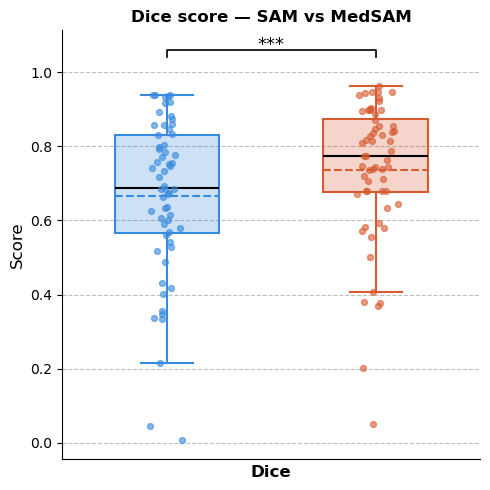

Figure sauvegardée : /home/cassa2/psy3019/projet_repro/output_data/Figures/figure_dice.png


In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
plot_boxplot(ax, 'dice', ylabel=True)
plt.title('Dice score — SAM vs MedSAM', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

filepath = os.path.join(figures_dir, "figure_dice.png")
fig.savefig(filepath, dpi=300, bbox_inches='tight')
plt.close(fig)
print(f"Figure sauvegardée : {filepath}")

# Figure Recall précision

Prend les mêmes éléments que le dice score mais donne plus d'information sur ou sont les erreurs du modèle 
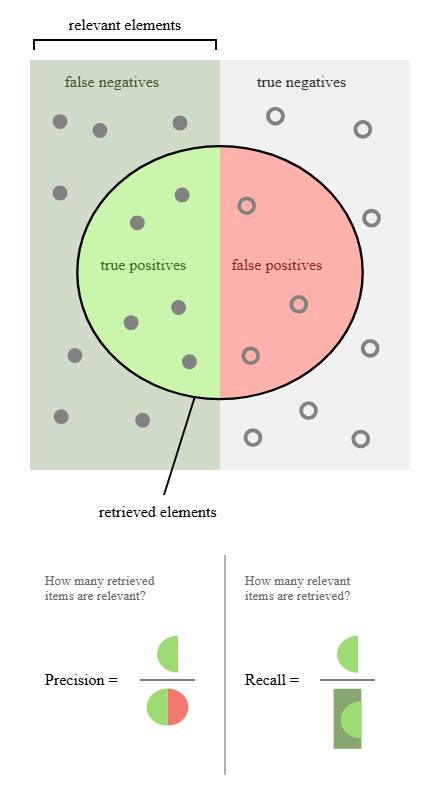

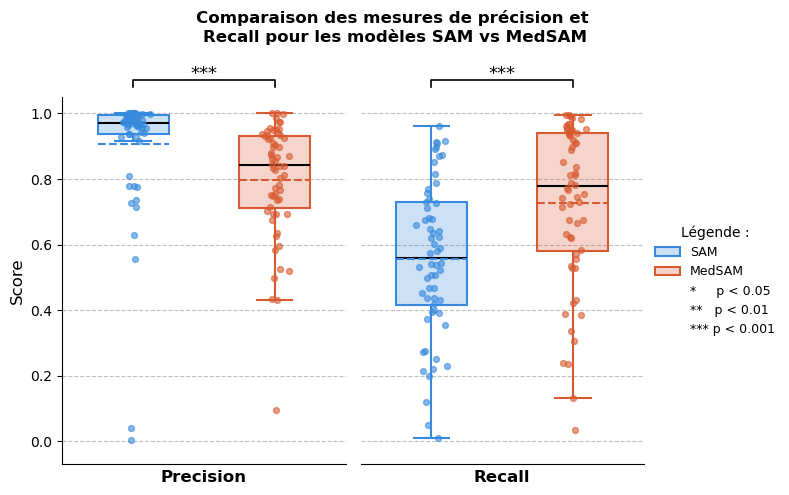

Figure sauvegardée : /home/cassa2/psy3019/projet_repro/output_data/Figures/figure_recall_precision.png


In [8]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 5), sharey=False)
plot_boxplot(ax1, 'precision', ylabel=True, ylim=(-0.07, 1.05))
plot_boxplot(ax2, 'recall', ylabel=False, ylim=(-0.07, 1.05))

# Légende externe sur ax2
legend_elements = [
    Patch(facecolor=couleurs['SAM'] + '40', edgecolor=couleurs['SAM'], linewidth=1.5, label='SAM'),
    Patch(facecolor=couleurs['MedSAM'] + '40', edgecolor=couleurs['MedSAM'], linewidth=1.5, label='MedSAM'),
    Line2D([0], [0], color='none', label='*     p < 0.05'),
    Line2D([0], [0], color='none', label='**   p < 0.01'),
    Line2D([0], [0], color='none', label='*** p < 0.001'),
]
ax2.legend(handles=legend_elements, title='Légende :', fontsize=9,
           frameon=False, loc='center left', bbox_to_anchor=(1, 0.5))

plt.suptitle('Comparaison des mesures de précision et \nRecall pour les modèles SAM vs MedSAM',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

filepath = os.path.join(figures_dir, "figure_recall_precision.png")
fig.savefig(filepath, dpi=300, bbox_inches='tight')
plt.close(fig)
print(f"Figure sauvegardée : {filepath}")

# Figure comparaison périmètre

Les deux métriques comparés ici sont le Hausdorff Distance (HD) et la distance moyenne entre les segmentations. Ces métriques seraient complémentaires aux métriques de chevauchement et plus sensible à des erreurs par rapport à la frontière de la tumeur (Sharp et al., 2014)

- HD correspond à la plus grande distance entre les deux segmentations, comme on peut le voir sur l'image. Cette métrique quantifie la présence de grands débordements. 
- La distance moyenne est moins sensible aux outliers et est moins sensible aux valeurs extrêmes et reflète la qualité globale de l'alignement des contours, en moyennant les distances entre les deux surfaces dans les deux directions.

![image.png](../HD.png)
https://www.researchgate.net/figure/Hausdorff-Distance-between-point-sets-X-and-Y-18_fig6_342520628
###### Source : Jadon, Shruti. « A survey of loss functions for semantic segmentation ». arXiv:2006.14822, arXiv, 3 septembre 2020. arXiv.org, https://doi.org/10.48550/arXiv.2006.14822.

Les deux métriques ont comme performance parfaite une valeur de 0 

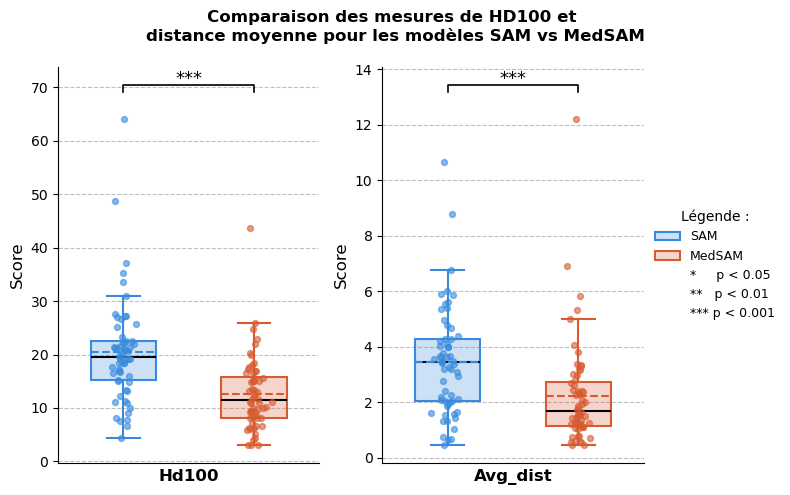

Figure sauvegardée : /home/cassa2/psy3019/projet_repro/output_data/Figures/figure_perimètre.png


In [9]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 5), sharey=False)
plot_boxplot(ax1, 'HD100', ylabel=True)
plot_boxplot(ax2, 'AVG_dist', ylabel=False)

# Légende externe sur ax2
legend_elements = [
    Patch(facecolor=couleurs['SAM'] + '40', edgecolor=couleurs['SAM'], linewidth=1.5, label='SAM'),
    Patch(facecolor=couleurs['MedSAM'] + '40', edgecolor=couleurs['MedSAM'], linewidth=1.5, label='MedSAM'),
    Line2D([0], [0], color='none', label='*     p < 0.05'),
    Line2D([0], [0], color='none', label='**   p < 0.01'),
    Line2D([0], [0], color='none', label='*** p < 0.001'),
]
ax2.legend(handles=legend_elements, title='Légende :', fontsize=9,
           frameon=False, loc='center left', bbox_to_anchor=(1, 0.5))

plt.suptitle('Comparaison des mesures de HD100 et \ndistance moyenne pour les modèles SAM vs MedSAM',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

filepath = os.path.join(figures_dir, "figure_perimètre.png")
fig.savefig(filepath, dpi=300, bbox_inches='tight')
plt.close(fig)
print(f"Figure sauvegardée : {filepath}")

## Sans outliers

In [10]:
# Même figure qu'en haut mais sans les grands outliers, détermine axe des y : 

def limites(metrique) : 
    vals_all = pd.concat([df_long[df_long['modele'] == m][metrique] for m in modeles])
    mean = vals_all.mean()
    std = vals_all.std()
    return (0, mean + 2.5 * std)


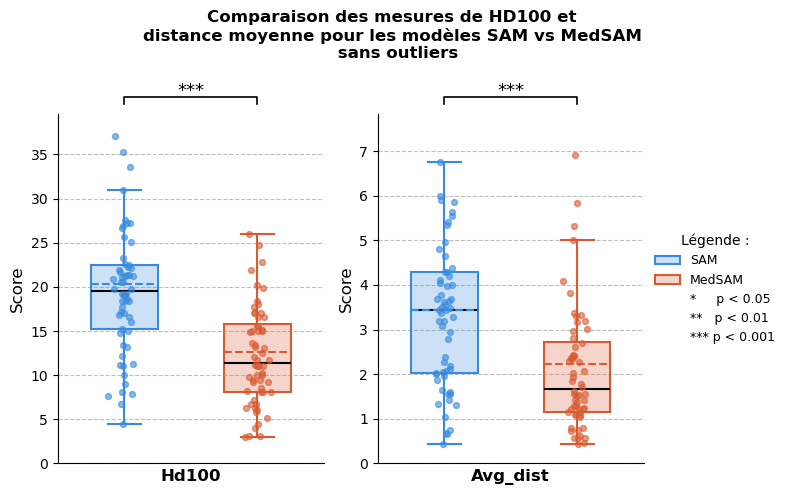

Figure sauvegardée : /home/cassa2/psy3019/projet_repro/output_data/Figures/figure_perimètre_no-outliers.png


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 5), sharey=False)

plot_boxplot(ax1, 'HD100', ylabel=True, ylim=limites('HD100'))
plot_boxplot(ax2, 'AVG_dist', ylabel=True, ylim=limites('AVG_dist'))

# Légende externe sur ax2
legend_elements = [
    Patch(facecolor=couleurs['SAM'] + '40', edgecolor=couleurs['SAM'], linewidth=1.5, label='SAM'),
    Patch(facecolor=couleurs['MedSAM'] + '40', edgecolor=couleurs['MedSAM'], linewidth=1.5, label='MedSAM'),
    Line2D([0], [0], color='none', label='*     p < 0.05'),
    Line2D([0], [0], color='none', label='**   p < 0.01'),
    Line2D([0], [0], color='none', label='*** p < 0.001'),
]
ax2.legend(handles=legend_elements, title='Légende :', fontsize=9,
           frameon=False, loc='center left', bbox_to_anchor=(1, 0.5))

plt.suptitle('Comparaison des mesures de HD100 et \ndistance moyenne pour les modèles SAM vs MedSAM \n sans outliers',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

filepath = os.path.join(figures_dir, "figure_perimètre_no-outliers.png")
fig.savefig(filepath, dpi=300, bbox_inches='tight')
plt.close(fig)
print(f"Figure sauvegardée : {filepath}")

# Figure comparaison Dice

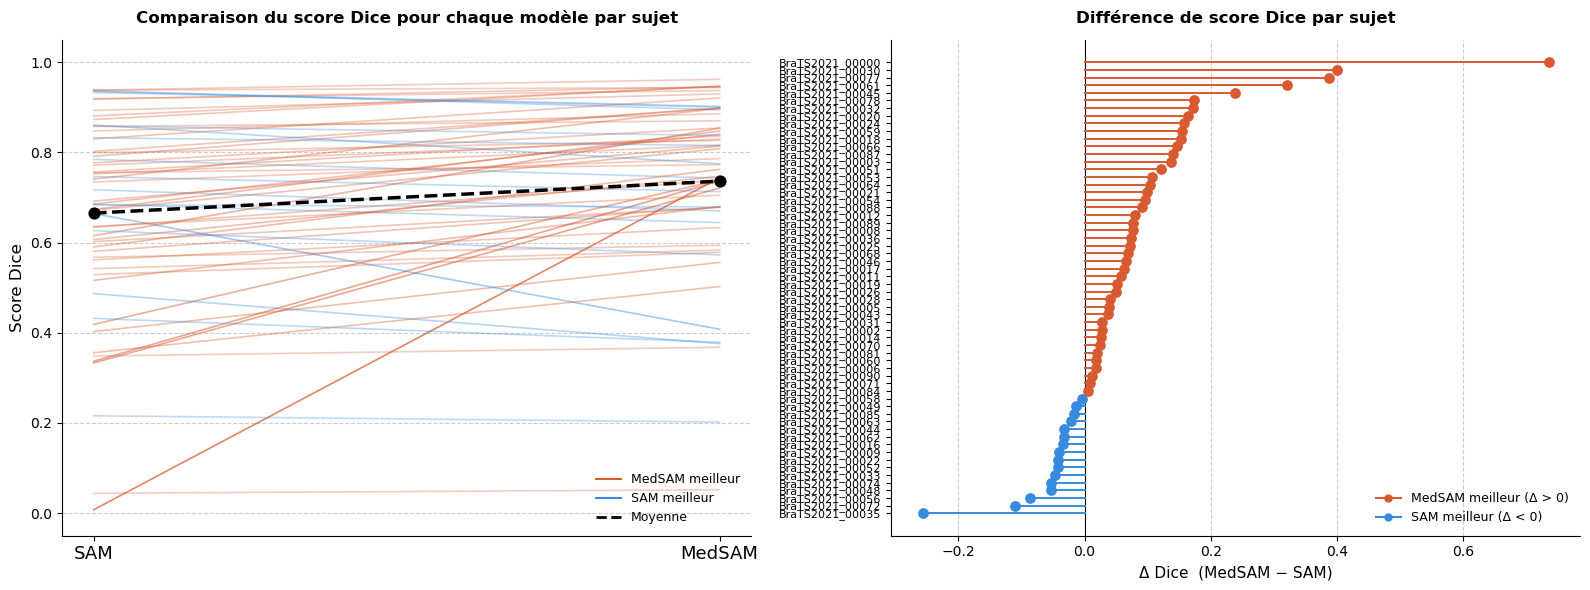

Figure sauvegardée : /home/cassa2/psy3019/projet_repro/output_data/Figures/figure_comparaison_dice.png


In [ ]:
couleurs = {'SAM': '#378ADD', 'MedSAM': '#D85A30'}

diff = tableau_resultat['medsam_dice'] - tableau_resultat['sam_dice']
subjects = tableau_resultat.index.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ── Parallel coordinates ──────────────────────────────────────────────────
for subj in subjects:
    sam_val    = tableau_resultat.loc[subj, 'sam_dice']
    medsam_val = tableau_resultat.loc[subj, 'medsam_dice']
    d = medsam_val - sam_val
    color  = '#D85A30' if d > 0 else '#378ADD'   # MedSAM better → coral, SAM better → blue
    alpha  = 0.3 + 0.6 * abs(d)                  # bigger difference = more opaque
    ax1.plot([0, 1], [sam_val, medsam_val],
                color=color, alpha=alpha, linewidth=1.2, zorder=2)

# Means
mu_sam    = tableau_resultat['sam_dice'].mean()
mu_medsam = tableau_resultat['medsam_dice'].mean()
ax1.plot([0, 1], [mu_sam, mu_medsam],
            color='black', linewidth=2.5, linestyle='--', zorder=5, label='Moyenne')
ax1.scatter([0, 1], [mu_sam, mu_medsam],
            color='black', s=60, zorder=6)

ax1.set_xticks([0, 1])
ax1.set_xticklabels(['SAM', 'MedSAM'], fontsize=13)
ax1.set_ylabel('Score Dice', fontsize=12)
ax1.set_ylim(-0.05, 1.05)
ax1.yaxis.grid(True, linestyle='--', alpha=0.4, color='gray')
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_title('Comparaison du score Dice pour chaque modèle par sujet', fontsize=12,
                fontweight='bold', pad=12)

legend_elems = [
    mlines.Line2D([], [], color='#D85A30', linewidth=1.5, label='MedSAM meilleur'),
    mlines.Line2D([], [], color='#378ADD', linewidth=1.5, label='SAM meilleur'),
    mlines.Line2D([], [], color='black',   linewidth=2,   linestyle='--', label='Moyenne'),
]
ax1.legend(handles=legend_elems, fontsize=9, frameon=False, loc='lower right')

# ── Lollipop — MedSAM − SAM ───────────────────────────────────────────────
order   = diff.sort_values().index          # sort by difference
y_pos   = np.arange(len(order))
diff_sorted = diff[order]

for i, (subj, val) in enumerate(diff_sorted.items()):
    color = '#D85A30' if val > 0 else '#378ADD'
    ax2.plot([0, val], [i, i], color=color, linewidth=1.4, zorder=2)
    ax2.scatter(val, i, color=color, s=45, zorder=3)

ax2.axvline(0, color='black', linewidth=0.8, linestyle='-', zorder=1)

# Option pour avoir le nom des sujets comme axe des y (après 30 sujets, trop chargé)
#ax2.set_yticks(y_pos)
#ax2.set_yticklabels(order, fontsize=8)

ax2.set_yticks([])
ax2.set_xlabel('Δ Dice  (MedSAM − SAM)', fontsize=11)
ax2.xaxis.grid(True, linestyle='--', alpha=0.4, color='gray')
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title('Différence de score Dice par sujet', fontsize=12,
                fontweight='bold', pad=12)

legend_elems2 = [
    mlines.Line2D([], [], color='#D85A30', linewidth=1.5,
                    marker='o', markersize=5, label='MedSAM meilleur (Δ > 0)'),
    mlines.Line2D([], [], color='#378ADD', linewidth=1.5,
                    marker='o', markersize=5, label='SAM meilleur (Δ < 0)'),
]
ax2.legend(handles=legend_elems2, fontsize=9, frameon=False, loc='lower right')

fig.tight_layout()

plt.show()

filepath = os.path.join(figures_dir, "figure_comparaison_dice.png")
fig.savefig(filepath, dpi=300, bbox_inches='tight')
plt.close(fig)
print(f"Figure sauvegardée : {filepath}")
